In [34]:
 # Author: Krutarth Parmar
 # Date: 2025-04-03

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import torch.nn as nn
import torch.nn.functional as F
import torch
import tensorflow as tf
import tensorflow.keras

# VAE Model instansiation


In [3]:
latent_dim = 16
intermediate_dim = 128

class VAE(nn.Module):
    def __init__(self, latent_dim=16, intermediate_dim=128):
        super(VAE, self).__init__()

        # --- Encoder ---
        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1) # -> (N, 32, 14, 14)
        self.bn1 = nn.BatchNorm2d(32) # Added BatchNorm
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1) # -> (N, 64, 7, 7)
        self.bn2 = nn.BatchNorm2d(64) # Added BatchNorm
        # Flattened size: 64 * 7 * 7 = 3136
        self.fc1 = nn.Linear(64 * 7 * 7, intermediate_dim)
        self.bn3 = nn.BatchNorm1d(intermediate_dim) # Added BatchNorm

        self.fc_mu = nn.Linear(intermediate_dim, latent_dim)
        self.fc_logvar = nn.Linear(intermediate_dim, latent_dim)

        # --- Decoder ---
        self.fc_decode1 = nn.Linear(latent_dim, intermediate_dim)
        self.bn4 = nn.BatchNorm1d(intermediate_dim) # Added BatchNorm
        self.fc_decode2 = nn.Linear(intermediate_dim, 64 * 7 * 7)
        self.bn5 = nn.BatchNorm1d(64 * 7 * 7) # Added BatchNorm

        self.conv_t1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1) # -> (N, 32, 14, 14)
        self.bn6 = nn.BatchNorm2d(32) # Added BatchNorm
        self.conv_t2 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1) # -> (N, 1, 28, 28)
        # NO BatchNorm before final Sigmoid

    def encode(self, x):
        # Apply Conv -> BatchNorm -> ReLU
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.view(x.size(0), -1) # Flatten
        x = F.relu(self.bn3(self.fc1(x)))
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x) # No activation/BN on mu/logvar outputs
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        # Apply Linear -> BatchNorm -> ReLU
        z = F.relu(self.bn4(self.fc_decode1(z)))
        z = F.relu(self.bn5(self.fc_decode2(z)))
        z = z.view(z.size(0), 64, 7, 7) # Reshape
        # Apply ConvTranspose -> BatchNorm -> ReLU
        z = F.relu(self.bn6(self.conv_t1(z)))
        # Final layer -> Sigmoid (NO BatchNorm here)
        reconstruction = torch.sigmoid(self.conv_t2(z))
        return reconstruction

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar



In [4]:
model = VAE(latent_dim=latent_dim, intermediate_dim=intermediate_dim)
model.load_state_dict(torch.load('vae_rotated_mnist_1_2_epoch8.pth'))

/var/folders/j3/l5m7q9lx3gqff5xrl7n7sck40000gn/T/ipykernel_23228/1788141676.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('vae_rotated

<All keys matched successfully>

# Load MNIST Rotated Data for digits 1 & 2


In [5]:
from scipy.ndimage import rotate

# download mnist data 
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_digits = []
y_labels = [] # To store 1 or 2

for i in range(len(x_train)):
    if y_train[i] == 1 or y_train[i] == 2:
        x_digits.append(x_train[i])
        y_labels.append(y_train[i]) # Store the label (1 or 2)

print(f"Found {len(x_digits)} images of digits 1 and 2.")
# Convert labels to numpy array for easier handling later if needed
y_labels = np.array(y_labels)

Found 12700 images of digits 1 and 2.


In [17]:
from scipy.ndimage import rotate
import numpy as np

rotated_images_all = {} # Dictionary to store images by angle
angles = range(0, 360, 30) # 0, 30, 60, ..., 330

for angle in angles:
    print(f"Rotating images by {angle} degrees...")
    rotated_list_for_angle = []
    if angle == 0:
        # No rotation needed for 0 degrees
        rotated_list_for_angle = [img for img in x_digits] # Use original images
    else:
        for img in x_digits:
            rotated_img = rotate(img, angle, reshape=False, mode='nearest') # Use mode='nearest' or 'constant'
            rotated_list_for_angle.append(rotated_img)

    # Store the list of numpy arrays for this angle
    rotated_images_all[angle] = np.array(rotated_list_for_angle) # Store as numpy array for consistency

print("Finished rotating images for all angles.")

Rotating images by 0 degrees...
Rotating images by 30 degrees...
Rotating images by 60 degrees...
Rotating images by 90 degrees...
Rotating images by 120 degrees...
Rotating images by 150 degrees...
Rotating images by 180 degrees...
Rotating images by 210 degrees...
Rotating images by 240 degrees...
Rotating images by 270 degrees...
Rotating images by 300 degrees...
Rotating images by 330 degrees...
Finished rotating images for all angles.


In [7]:
import torch

model.eval() # Set model to evaluation mode

latent_vectors_all = {} # Dictionary to store latent vectors (mu) by angle

with torch.no_grad(): # Disable gradient calculations
    for angle in angles:
        print(f"Encoding images for {angle} degrees...")
        images_np = rotated_images_all[angle]

        # Convert numpy array to PyTorch tensor, add channel dimension
        images_tensor = torch.tensor(images_np, dtype=torch.float32).unsqueeze(1)
        images_tensor = images_tensor / 255.0

        mu, logvar = model.encode(images_tensor)

        # Store the mu vectors (latent representations) as numpy arrays
        latent_vectors_all[angle] = mu.cpu().numpy()

print("Finished encoding images for all angles.")

Encoding images for 0 degrees...
Encoding images for 30 degrees...
Encoding images for 60 degrees...
Encoding images for 90 degrees...
Encoding images for 120 degrees...
Encoding images for 150 degrees...
Encoding images for 180 degrees...
Encoding images for 210 degrees...
Encoding images for 240 degrees...
Encoding images for 270 degrees...
Encoding images for 300 degrees...
Encoding images for 330 degrees...
Finished encoding images for all angles.


In [8]:
X_mlp = []
y_mlp = []

angles_list = list(angles) # [0, 30, ..., 330]

for i in range(len(angles_list)):
    current_angle = angles_list[i]
    # Calculate the next angle, handling wrap-around (330 -> 0)
    next_angle_index = (i + 1) % len(angles_list)
    next_angle = angles_list[next_angle_index]

    print(f"Pairing: {current_angle}° -> {next_angle}°")

    # Get the latent vectors for the current and next angles
    z_theta = latent_vectors_all[current_angle]       # Shape: (num_images, latent_dim)
    z_theta_plus_30 = latent_vectors_all[next_angle] # Shape: (num_images, latent_dim)

    # Add them to our MLP training lists
    X_mlp.append(z_theta)
    y_mlp.append(z_theta_plus_30)

# Concatenate lists of arrays into single large arrays
X_mlp = np.concatenate(X_mlp, axis=0) # Shape: (num_images * 12, latent_dim)
y_mlp = np.concatenate(y_mlp, axis=0) # Shape: (num_images * 12, latent_dim)

print(f"MLP Input Shape: {X_mlp.shape}")
print(f"MLP Target Shape: {y_mlp.shape}")

Pairing: 0° -> 30°
Pairing: 30° -> 60°
Pairing: 60° -> 90°
Pairing: 90° -> 120°
Pairing: 120° -> 150°
Pairing: 150° -> 180°
Pairing: 180° -> 210°
Pairing: 210° -> 240°
Pairing: 240° -> 270°
Pairing: 270° -> 300°
Pairing: 300° -> 330°
Pairing: 330° -> 0°
MLP Input Shape: (152400, 16)
MLP Target Shape: (152400, 16)


Created 152400 labels for 152400 data points.
Applying t-SNE... (This may take a while for large datasets)


/opt/homebrew/anaconda3/envs/tf-m1/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE finished.
Plotting t-SNE results...


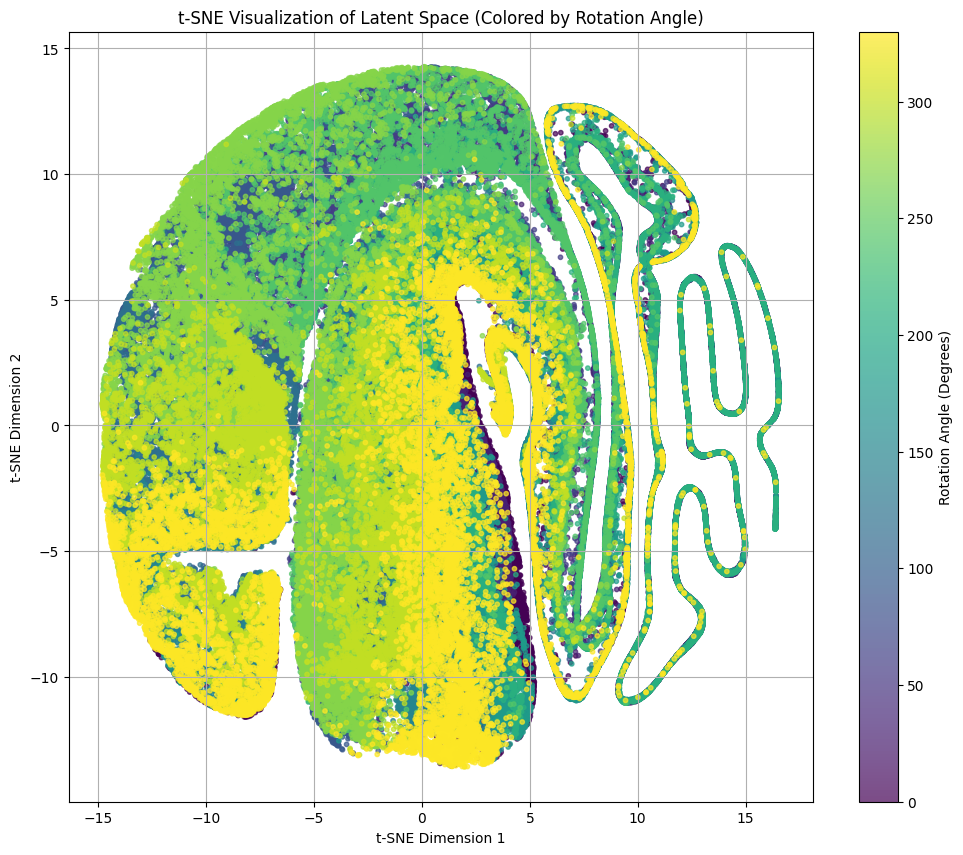

Plot displayed.


In [9]:

from sklearn.manifold import TSNE

# Determine the number of original images per angle block
# Assuming all angles have the same number of images/vectors
num_images_per_angle = latent_vectors_all[0].shape[0]
num_angles = len(angles_list)

# --- 1. Create Labels for Visualization (Original Angle) ---

angle_labels = []
for angle in angles_list:
    # Assign the current angle as the label for all images processed at this angle
    angle_labels.extend([angle] * num_images_per_angle)

angle_labels = np.array(angle_labels)

# Check if the length matches X_mlp's first dimension
if len(angle_labels) != X_mlp.shape[0]:
    print("Warning: Label count mismatch! Check data construction.")
    # Handle potential error or recalculate based on X_mlp.shape[0] if certain

print(f"Created {len(angle_labels)} labels for {X_mlp.shape[0]} data points.")

# --- 2. Apply t-SNE ---

print("Applying t-SNE... (This may take a while for large datasets)")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300, init='pca', learning_rate='auto')
X_mlp_2d = tsne.fit_transform(X_mlp)

print("t-SNE finished.")

# --- 3. Visualize the 2D Projection ---

print("Plotting t-SNE results...")
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_mlp_2d[:, 0], X_mlp_2d[:, 1], c=angle_labels, cmap='viridis', alpha=0.7, s=10) # s=10 for smaller points
plt.title('t-SNE Visualization of Latent Space (Colored by Rotation Angle)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# Add a colorbar to show mapping from color to angle
cbar = plt.colorbar(scatter)
cbar.set_label('Rotation Angle (Degrees)')

plt.grid(True)
plt.show()
print("Plot displayed.")

In [10]:
import torch.nn as nn

latent_dim = 16 
hidden_dim = 128 

mlp_model = nn.Sequential(
    nn.Linear(latent_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim), #  second hidden layer
    nn.ReLU(),                     #  second activation
    nn.Linear(hidden_dim, latent_dim) # Final linear output layer
)

print(mlp_model)

Sequential(
  (0): Linear(in_features=16, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=16, bias=True)
)


In [11]:
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

# --- 1. Prepare Data for PyTorch ---

# Convert NumPy arrays to PyTorch tensors
# Ensure dtype is torch.float32 as neural networks typically work with floats
X_tensor = torch.tensor(X_mlp, dtype=torch.float32)
y_tensor = torch.tensor(y_mlp, dtype=torch.float32)

# Create a TensorDataset (combines inputs and targets)
dataset = TensorDataset(X_tensor, y_tensor)

# Create a DataLoader (handles batching and shuffling)
batch_size = 64 # Choose a suitable batch size
shuffle_data = True # Shuffle data each epoch
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle_data)

# --- 2. Define Loss Function and Optimizer ---

# Loss Function (Mean Squared Error for regression)
criterion = nn.MSELoss()

# Optimizer (Adam is a common choice)
learning_rate = 0.001 # Choose a suitable learning rate
optimizer = optim.Adam(mlp_model.parameters(), lr=learning_rate)

# --- 3. Training Loop ("Fitting") ---

# Choose device (GPU if available, otherwise CPU)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_epochs = 20 # Choose the number of epochs

print("Starting training...")
for epoch in range(num_epochs):
    mlp_model.train() # Set the model to training mode
    running_loss = 0.0
    num_batches = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to the same device as the model
        # inputs, targets = inputs.to(device), targets.to(device)

        # --- Forward pass ---
        outputs = mlp_model(inputs)
        loss = criterion(outputs, targets)

        # --- Backward pass and optimization ---
        optimizer.zero_grad() # Clear previous gradients
        loss.backward()       # Calculate gradients
        optimizer.step()      # Update weights

        running_loss += loss.item()
        num_batches += 1

        #  Print progress within an epoch
        if batch_idx % 100 == 99: # Print every 100 batches
           print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

    # Calculate average loss for the epoch
    epoch_loss = running_loss / num_batches
    print(f"Epoch [{epoch+1}/{num_epochs}] completed. Average Loss: {epoch_loss:.6f}")

print("Training finished.")

# --- 4. Save the trained model ---
torch.save(mlp_model.state_dict(), 'mlp_rotation_model_1_2.pth')

Starting training...
Epoch [1/20], Batch [100/2382], Loss: 516.0539
Epoch [1/20], Batch [200/2382], Loss: 1115.7460
Epoch [1/20], Batch [300/2382], Loss: 463.9506
Epoch [1/20], Batch [400/2382], Loss: 227.5825
Epoch [1/20], Batch [500/2382], Loss: 206.6644
Epoch [1/20], Batch [600/2382], Loss: 153.2731
Epoch [1/20], Batch [700/2382], Loss: 93.5533
Epoch [1/20], Batch [800/2382], Loss: 115.1141
Epoch [1/20], Batch [900/2382], Loss: 83.9413
Epoch [1/20], Batch [1000/2382], Loss: 158.5488
Epoch [1/20], Batch [1100/2382], Loss: 83.6100
Epoch [1/20], Batch [1200/2382], Loss: 70.2930
Epoch [1/20], Batch [1300/2382], Loss: 359.8156
Epoch [1/20], Batch [1400/2382], Loss: 129.7860
Epoch [1/20], Batch [1500/2382], Loss: 125.1040
Epoch [1/20], Batch [1600/2382], Loss: 82.6568
Epoch [1/20], Batch [1700/2382], Loss: 63.5876
Epoch [1/20], Batch [1800/2382], Loss: 52.2737
Epoch [1/20], Batch [1900/2382], Loss: 165.4908
Epoch [1/20], Batch [2000/2382], Loss: 55.0652
Epoch [1/20], Batch [2100/2382], Lo

# Test model inference


In [18]:
x_digits_test = []
y_labels_test = [] # To store 1 or 2

for i in range(len(x_test)):
    if y_test[i] == 1 or y_test[i] == 2:
        x_digits_test.append(x_test[i])
        y_labels_test.append(y_test[i]) # Store the label (1 or 2)

print(f"Found {len(x_digits_test)} images of digits 1 and 2 in TEST.")
# Convert labels to numpy array for easier handling later if needed
y_labels_test = np.array(y_labels_test)

Found 2167 images of digits 1 and 2 in TEST.


In [19]:
rotated_images_all_test = {} # Dictionary to store images by angle

for angle in angles:
    print(f"Rotating images by {angle} degrees...")
    rotated_list_for_angle_test = []
    if angle == 0:
        # No rotation needed for 0 degrees
        rotated_list_for_angle = [img for img in x_digits_test] # Use original images
    else:
        for img in x_digits_test:
            # Apply rotation [cite: 13] - Make sure reshape=False if you want to keep original dimensions (28x28)
            # If reshape=True, images might get larger, which could affect your VAE input size.
            # Check your VAE input requirements. Assuming reshape=False might be safer.
            rotated_img_test = rotate(img, angle, reshape=False, mode='nearest') # Use mode='nearest' or 'constant'
            rotated_list_for_angle_test.append(rotated_img_test)

    # Store the list of numpy arrays for this angle
    rotated_images_all_test[angle] = np.array(rotated_list_for_angle_test) # Store as numpy array for consistency

print("Finished rotating images for all angles.")

Rotating images by 0 degrees...
Rotating images by 30 degrees...
Rotating images by 60 degrees...
Rotating images by 90 degrees...
Rotating images by 120 degrees...
Rotating images by 150 degrees...
Rotating images by 180 degrees...
Rotating images by 210 degrees...
Rotating images by 240 degrees...
Rotating images by 270 degrees...
Rotating images by 300 degrees...
Rotating images by 330 degrees...
Finished rotating images for all angles.


In [22]:
images_np_test = rotated_images_all_test[angle]

In [23]:
latent_vectors_all_test = {}

with torch.no_grad():
    for angle in angles:
        print(f"Encoding images for {angle} degrees...")
        images_np_test = rotated_images_all_test[angle]

        if images_np_test.shape[0] == 0:
            print(f"Skipping {angle} degrees because there are no images.")
            continue

        # Convert numpy array to PyTorch tensor, add channel dimension
        images_tensor_test = torch.tensor(images_np_test, dtype=torch.float32).unsqueeze(1)

        mu_test, logvar_test = model.encode(images_tensor_test)

        latent_vectors_all_test[angle] = mu_test.cpu().numpy()

print("Finished encoding images for all angles.")


Encoding images for 0 degrees...
Skipping 0 degrees because there are no images.
Encoding images for 30 degrees...
Encoding images for 60 degrees...
Encoding images for 90 degrees...
Encoding images for 120 degrees...
Encoding images for 150 degrees...
Encoding images for 180 degrees...
Encoding images for 210 degrees...
Encoding images for 240 degrees...
Encoding images for 270 degrees...
Encoding images for 300 degrees...
Encoding images for 330 degrees...
Finished encoding images for all angles.


In [31]:
X_mlp_test = []
y_mlp_test = []

available_angles = list(latent_vectors_all_test.keys())  # Use only angles that were successfully encoded
angles_list = sorted(available_angles)  # Make sure angles are in order

for i in range(len(angles_list)):
    current_angle = angles_list[i]
    next_angle = angles_list[(i + 1) % len(angles_list)]

    # Skip if either current or next angle is missing
    if current_angle not in latent_vectors_all_test or next_angle not in latent_vectors_all_test:
        print(f"Skipping pair ({current_angle}, {next_angle}) due to missing data.")
        continue

    z_theta = latent_vectors_all_test[current_angle]
    z_theta_plus_30 = latent_vectors_all_test[next_angle]

    X_mlp_test.append(z_theta)
    y_mlp_test.append(z_theta_plus_30)

# Concatenate to get full arrays
x_mlp_test = np.concatenate(X_mlp_test, axis=0)
y_mlp_test = np.concatenate(y_mlp_test, axis=0)

print(f"MLP Input Shape: {x_mlp_test.shape}")
print(f"MLP Target Shape: {y_mlp_test.shape}")


MLP Input Shape: (23837, 16)
MLP Target Shape: (23837, 16)


In [32]:
X_test_tensor = torch.tensor(x_mlp_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_mlp_test, dtype=torch.float32)

criterion = nn.MSELoss()

with torch.no_grad(): # No need to calculate gradients during testing
    predictions = mlp_model(X_test_tensor)
    test_loss = criterion(predictions, y_test_tensor)

print(f"Test Loss (MSE): {test_loss.item():.6f}")

Test Loss (MSE): 11798167.000000


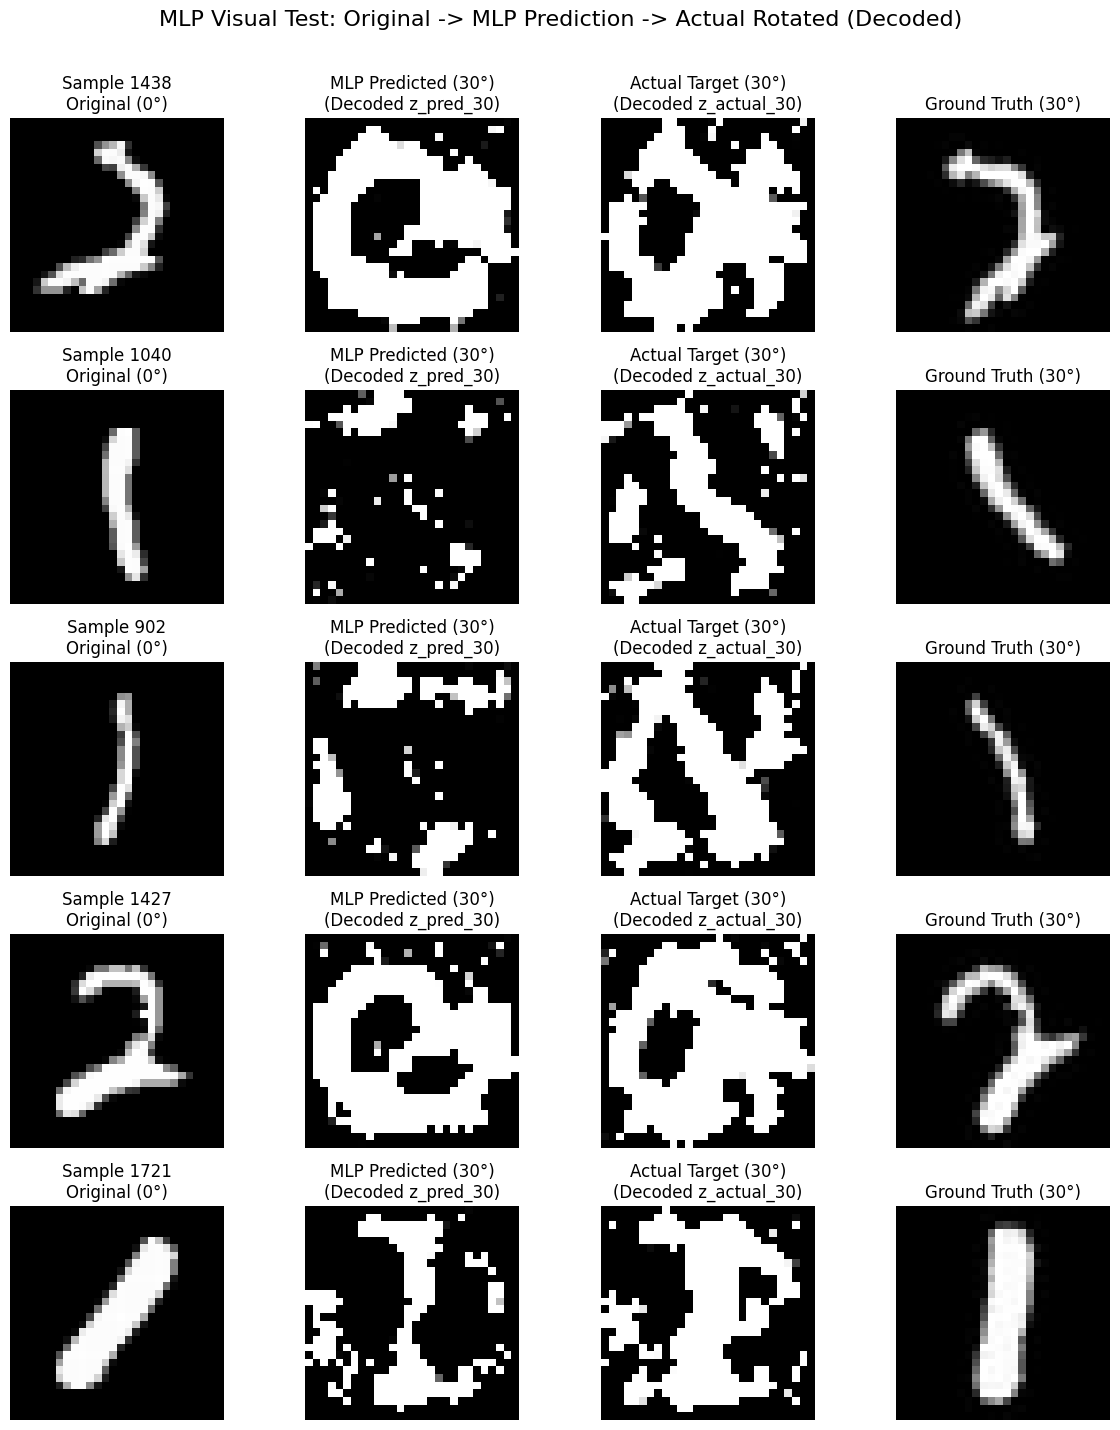

In [ ]:
mlp_model.eval()

# Ensure you have the test data available (e.g., x_digits_test)
# and the dictionary of actual rotated test images (rotated_images_all_test)
# and the dictionary of actual encoded test latent vectors (latent_vectors_all_test)

# --- Choose Samples to Visualize ---
num_samples_to_show = 5
# Select some indices from your test set
sample_indices = np.random.choice(len(x_digits_test), num_samples_to_show, replace=False)

# --- Perform Visualization ---
fig, axes = plt.subplots(num_samples_to_show, 4, figsize=(12, 3 * num_samples_to_show))
if num_samples_to_show == 1: # Handle case for single sample plot
    axes = np.array([axes])

fig.suptitle("MLP Visual Test: Original -> MLP Prediction -> Actual Rotated (Decoded)", fontsize=16)


with torch.no_grad(): # Ensure no gradients are calculated
    for i, idx in enumerate(sample_indices):
        # 1. Get Original Image and Target Rotated Image
        original_img_np = x_digits_test[idx]
        target_rotated_img_np = rotated_images_all_test[30][idx] # Get the actual 30-deg rotated image

        # 2. Encode Original Image (0 degrees)
        img_tensor = torch.tensor(original_img_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0) # Add batch and channel dims
        # Normalize if you did during training/encoding
        # img_tensor = img_tensor / 255.0
        # Move to device if needed: img_tensor = img_tensor.to(device)
        z_0, _ = model.encode(img_tensor) # Get latent vector (mu)

        # 3. Use MLP to Predict z_30
        # Ensure z_0 is on the correct device if MLP is on GPU
        z_pred_30 = mlp_model(z_0)

        # Ensure your latent_vectors_all_test is structured correctly
        z_actual_30 = torch.tensor(latent_vectors_all_test[30][idx], dtype=torch.float32).unsqueeze(0)

        # 5. Decode latent vectors back to images
        # Ensure z vectors are on the correct device if VAE model is on GPU
        recon_original = model.decode(z_0).cpu().squeeze().numpy()
        recon_pred_30 = model.decode(z_pred_30).cpu().squeeze().numpy()
        recon_actual_30 = model.decode(z_actual_30).cpu().squeeze().numpy()


        # 6. Plotting
        # Original Input Image
        ax = axes[i, 0]
        ax.imshow(original_img_np, cmap='gray')
        ax.set_title(f"Sample {idx}\nOriginal (0°)")
        ax.axis('off')

        # Reconstructed MLP Prediction
        ax = axes[i, 1]
        ax.imshow(recon_pred_30, cmap='gray')
        ax.set_title("MLP Predicted (30°)\n(Decoded z_pred_30)")
        ax.axis('off')

        # Reconstructed Actual Target (Optional but good comparison)
        ax = axes[i, 2]
        ax.imshow(recon_actual_30, cmap='gray')
        ax.set_title("Actual Target (30°)\n(Decoded z_actual_30)")
        ax.axis('off')

        # Actual Rotated Image
        ax = axes[i, 3]
        ax.imshow(target_rotated_img_np, cmap='gray')
        ax.set_title("Ground Truth (30°)")
        ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout to prevent title overlap
plt.show()